# Lab 6: Comparison of Logistic Regression and K Nearest Neighbors (KNN) Classifiers

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, ConfusionMatrixDisplay,
                              classification_report)

np.random.seed(42)
plt.rcParams['figure.figsize'] = (6, 5)

## Task 1: Load the Dataset

In [18]:
columns = [
    "id", "diagnosis",
    "radius_mean", "texture_mean", "perimeter_mean", "area_mean",
    "smoothness_mean", "compactness_mean", "concavity_mean",
    "concave_points_mean", "symmetry_mean", "fractal_dimension_mean",

    "radius_se", "texture_se", "perimeter_se", "area_se",
    "smoothness_se", "compactness_se", "concavity_se",
    "concave_points_se", "symmetry_se", "fractal_dimension_se",

    "radius_worst", "texture_worst", "perimeter_worst", "area_worst",
    "smoothness_worst", "compactness_worst", "concavity_worst",
    "concave_points_worst", "symmetry_worst", "fractal_dimension_worst"
]

df = pd.read_csv("wdbc.data", header=None, names=columns)

df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [19]:
target_names = ['malignant', 'benign']

df = df.drop(columns='id')
df['target'] = df['diagnosis'].map({'M': 0, 'B': 1})   # 0 = malignant, 1 = benign
df = df.drop(columns='diagnosis')

print("Shape of dataset:", df.shape)
print("Class names:", target_names)
df.head()

Shape of dataset: (569, 31)
Class names: ['malignant', 'benign']


,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,symmetry_mean,fractal_dimension_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [20]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   radius_mean              569 non-null    float64
 1   texture_mean             569 non-null    float64
 2   perimeter_mean           569 non-null    float64
 3   area_mean                569 non-null    float64
 4   smoothness_mean          569 non-null    float64
 5   compactness_mean         569 non-null    float64
 6   concavity_mean           569 non-null    float64
 7   concave_points_mean      569 non-null    float64
 8   symmetry_mean            569 non-null    float64
 9   fractal_dimension_mean   569 non-null    float64
 10  radius_se                569 non-null    float64
 11  texture_se               569 non-null    float64
 12  perimeter_se             569 non-null    float64
 13  area_se                  569 non-null    float64
 14  smoothness_se            569 non-null

## Task 2: Exploratory Data Analysis and Preprocessing

In [21]:
print("Total missing values:", df.isnull().sum().sum())
print("Number of duplicate rows:", df.duplicated().sum())
print()
print("Class distribution:")
print(df['target'].value_counts().rename({0: 'malignant', 1: 'benign'}))

Total missing values: 0
Number of duplicate rows: 0

Class distribution:
target
benign       357
malignant    212
Name: count, dtype: int64


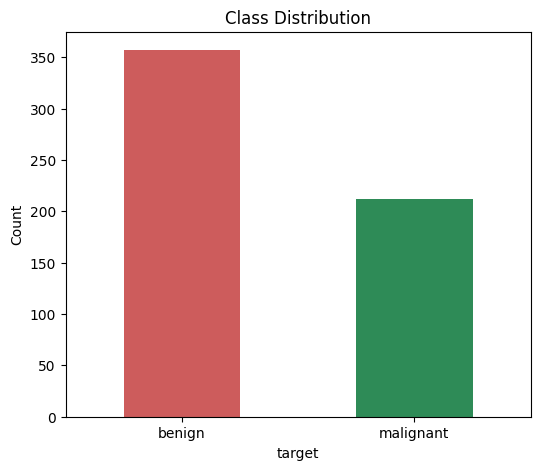

In [22]:
df['target'].value_counts().rename({0: 'malignant', 1: 'benign'}).plot(
    kind='bar', color=['indianred', 'seagreen'])
plt.title('Class Distribution')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

In [23]:
df.describe().T[['mean', 'std', 'min', 'max']]

,mean,std,min,max
radius_mean,14.127292,3.524049,6.981000,28.11000
texture_mean,19.289649,4.301036,9.710000,39.28000
perimeter_mean,91.969033,24.298981,43.790000,188.50000
area_mean,654.889104,351.914129,143.500000,2501.00000
smoothness_mean,0.096360,0.014064,0.052630,0.16340
compactness_mean,0.104341,0.052813,0.019380,0.34540
concavity_mean,0.088799,0.079720,0.000000,0.42680
concave_points_mean,0.048919,0.038803,0.000000,0.20120
symmetry_mean,0.181162,0.027414,0.106000,0.30400
fractal_dimension_mean,0.062798,0.007060,0.049960,0.09744


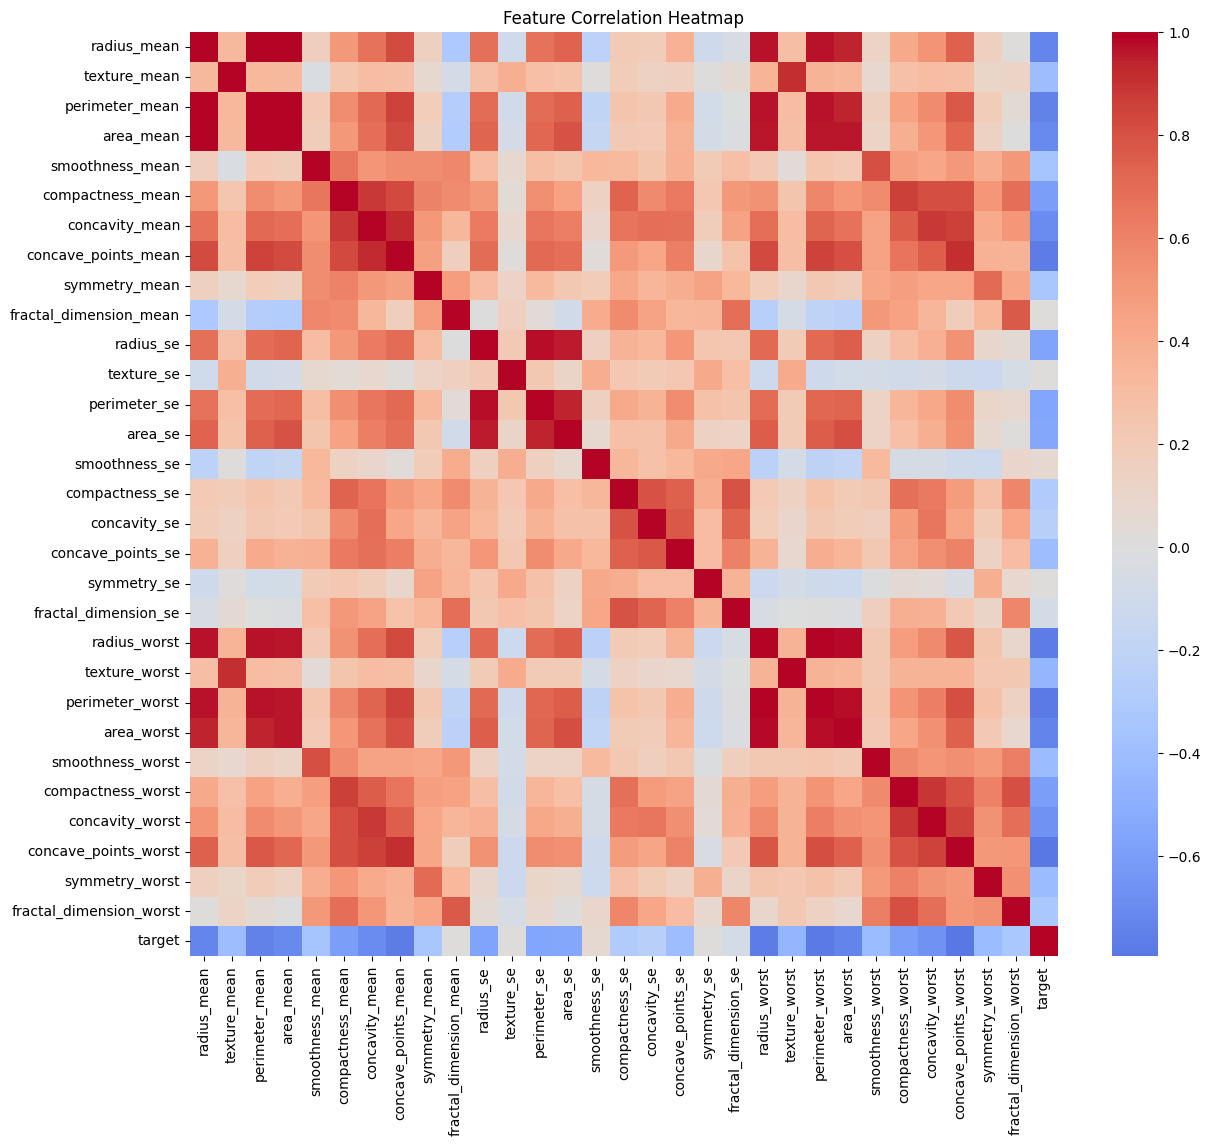

In [24]:
plt.figure(figsize=(14, 12))
sns.heatmap(df.corr(), cmap='coolwarm', center=0)
plt.title('Feature Correlation Heatmap')
plt.show()

The dataset has no missing values and no duplicate rows. All 30 features are numeric, so the only preprocessing required is feature scaling before training distance-based and gradient-based models.

## Task 3: Feature and Target Selection

In [25]:
X = df.drop(columns='target')
y = df['target']

print("Number of input features:", X.shape[1])
print("Target variable: target (0 = malignant, 1 = benign)")

Number of input features: 30
Target variable: target (0 = malignant, 1 = benign)


## Task 4: Train-Test Split

In [26]:
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_test = scaler.transform(X_test_raw)

print("Train shape:", X_train.shape, " Test shape:", X_test.shape)

Train shape: (455, 30)  Test shape: (114, 30)


## Task 5: Logistic Regression Classifier

In [27]:
log_reg = LogisticRegression(max_iter=10000, random_state=42)
log_reg.fit(X_train, y_train)

y_pred_lr = log_reg.predict(X_test)
print("Logistic Regression trained.")

Logistic Regression trained.


c:\Users\ncmia\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:451: OptimizeWarning: Unknown solver options: iprint
  opt_res = optimize.minimize(


## Task 6: K Nearest Neighbors Classifier


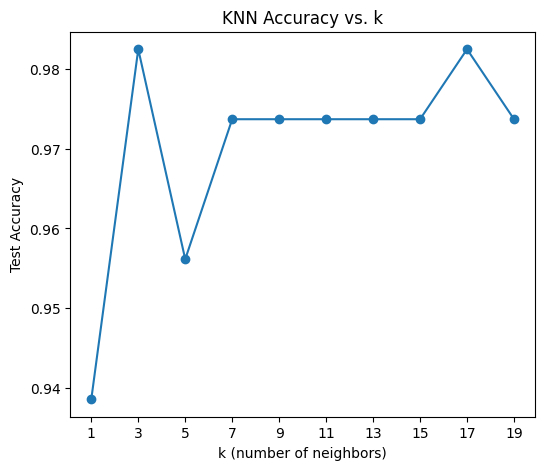

Best k: 3  (accuracy = 0.9825)


In [28]:
k_values = range(1, 21, 2)
k_accuracies = []
for k in k_values:
    knn_k = KNeighborsClassifier(n_neighbors=k)
    knn_k.fit(X_train, y_train)
    k_accuracies.append(accuracy_score(y_test, knn_k.predict(X_test)))

plt.figure()
plt.plot(list(k_values), k_accuracies, marker='o')
plt.xlabel('k (number of neighbors)')
plt.ylabel('Test Accuracy')
plt.title('KNN Accuracy vs. k')
plt.xticks(list(k_values))
plt.show()

best_k = list(k_values)[int(np.argmax(k_accuracies))]
print(f"Best k: {best_k}  (accuracy = {max(k_accuracies):.4f})")

In [29]:
knn = KNeighborsClassifier(n_neighbors=best_k)
knn.fit(X_train, y_train)

y_pred_knn = knn.predict(X_test)
print(f"KNN trained with k = {best_k}.")

KNN trained with k = 3.


## Task 7: Model Evaluation

In [30]:
def evaluate(name, y_true, y_pred):
    return {
        'Model': name,
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred),
        'Recall': recall_score(y_true, y_pred),
        'F1 Score': f1_score(y_true, y_pred),
    }

results = pd.DataFrame([
    evaluate('Logistic Regression', y_test, y_pred_lr),
    evaluate('KNN', y_test, y_pred_knn),
]).set_index('Model')

results.round(4)

,Accuracy,Precision,Recall,F1 Score
Model,,,,
Logistic Regression,0.9825,0.9861,0.9861,0.9861
KNN,0.9825,0.9730,1.0000,0.9863


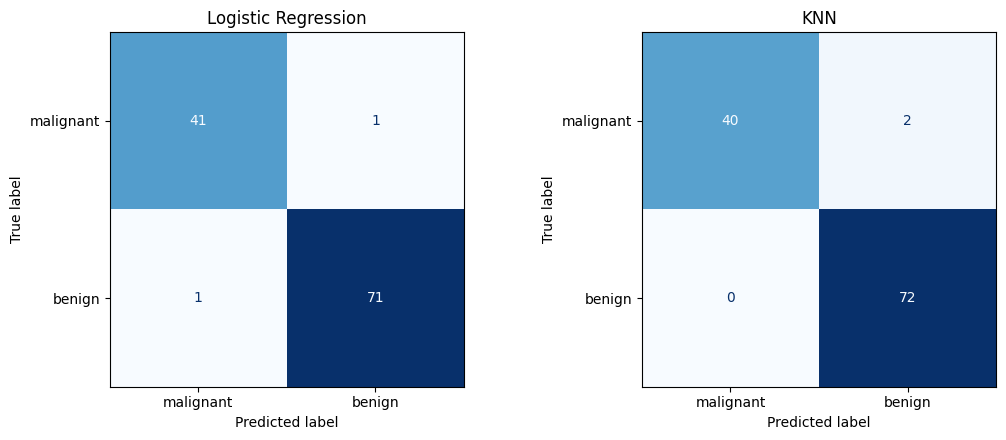

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

for ax, (name, y_pred) in zip(axes, [('Logistic Regression', y_pred_lr), ('KNN', y_pred_knn)]):
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=target_names)
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(name)

plt.tight_layout()
plt.show()

In [32]:
print("Logistic Regression classification report:")
print(classification_report(y_test, y_pred_lr, target_names=target_names))
print("KNN classification report:")
print(classification_report(y_test, y_pred_knn, target_names=target_names))

Logistic Regression classification report:
              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        42
      benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114

KNN classification report:
              precision    recall  f1-score   support

   malignant       1.00      0.95      0.98        42
      benign       0.97      1.00      0.99        72

    accuracy                           0.98       114
   macro avg       0.99      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



## Task 8: Comparison Table

In [33]:
comparison = results.round(4)
comparison.loc['Better Classifier'] = comparison.idxmax()
comparison

,Accuracy,Precision,Recall,F1 Score
Model,,,,
Logistic Regression,0.9825,0.9861,0.9861,0.9861
KNN,0.9825,0.973,1.0,0.9863
Better Classifier,Logistic Regression,Logistic Regression,KNN,KNN


## Interpretation and Conclusion

Both models did very well on this dataset, correctly classifying about 98% of the test samples.

Logistic Regression makes fewer false alarms (higher precision), while KNN catches every benign case correctly but misses a couple more malignant cases.

In a medical setting, missing a malignant case is worse than a false alarm, so Logistic Regression's more balanced performance makes it the safer choice here.